Install dependencies and import libraries

In [ ]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
!pip install kaggle

!kaggle datasets download -d nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone --unzip -p ./ct_kidney

Dataset URL: https://www.kaggle.com/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone
License(s): copyright-authors
100% 1.52G/1.52G [00:09<00:00, 167MB/s]



Load images and labels into DataFrame

In [ ]:
# Path to downloaded dataset
dataset_dir = "./ct_kidney"

# Get all image file paths
image_paths = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)

# Extract labels from folder names
labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]

# Create DataFrame
df = pd.DataFrame({"image_path": image_paths, "label": labels})
print("Total images:", len(df))
print(df.head())

Total images: 12446
                                          image_path   label
0  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Normal
1  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Normal
2  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Normal
3  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Normal
4  ./ct_kidney/CT-KIDNEY-DATASET-Normal-Cyst-Tumo...  Normal


Encode labels and split dataset

In [ ]:
# Encode string labels to integers
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Split into train, val, test (80-10-10)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label_enc'], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df['label_enc'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 8960, Val: 996, Test: 2490


Create ImageDataGenerators with augmentation

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 8960 validated image filenames belonging to 4 classes.
Found 996 validated image filenames belonging to 4 classes.
Found 2490 validated image filenames belonging to 4 classes.


Build Custom CNN

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1],3)),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(4, activation='softmax')  # 4 classes
])

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 111, 111, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 54, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,372 (42.61 MB)

 Trainable params: 11,169,924 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Train Custom CNN

In [ ]:
EPOCHS = 20
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 155s 259ms/step - accuracy: 0.5142 - loss: 1.7056 - val_accuracy: 0.6345 - val_loss: 0.9587
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 143s 254ms/step - accuracy: 0.5855 - loss: 1.0752 - val_accuracy: 0.5502 - val_loss: 1.2646
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 143s 255ms/step - accuracy: 0.6046 - loss: 1.0241 - val_accuracy: 0.6616 - val_loss: 0.8088
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 143s 255ms/step - accuracy: 0.6115 - loss: 0.9671 - val_accuracy: 0.6647 - val_loss: 0.8537
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 141s 252ms/step - accuracy: 0.6213 - loss: 0.9339 - val_accuracy: 0.6968 - val_loss: 0.7477
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 143s 255ms/step - accuracy: 0.6238 - loss: 0.9242 - val_accuracy: 0.6446 - val_loss: 0.9392
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 142s 253ms/step - accuracy: 0.6164 - loss: 0.9194 - val_accuracy: 0.6727 - val_loss: 0.7704
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 141s 251ms/step - accuracy: 0.6301 -

Evaluate on test set

In [ ]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.8944 - loss: 0.3684
Test Accuracy: 89.44%


156/156 ━━━━━━━━━━━━━━━━━━━━ 19s 114ms/step


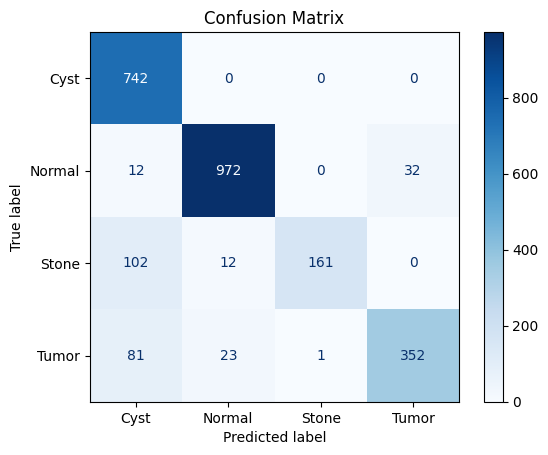

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


# 1. Confusion Matrix
# Get predictions
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes  # true labels from generator

# Display confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(cm, display_labels=test_gen.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

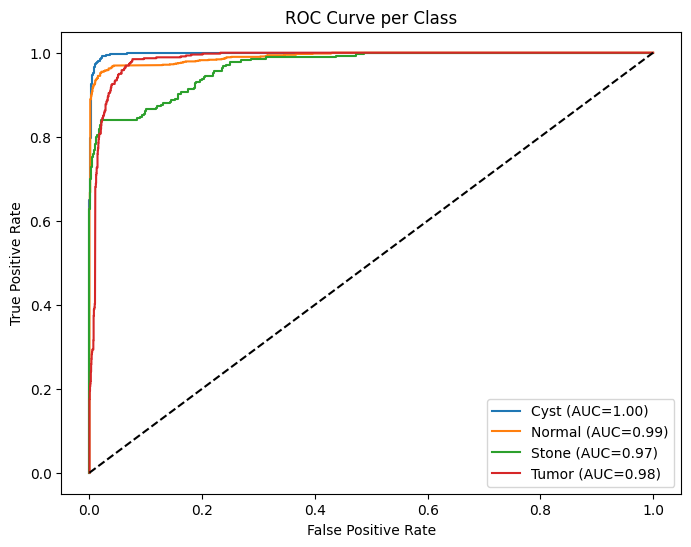

In [ ]:
# --- 2. ROC Curves for Each Class ---
from sklearn.preprocessing import label_binarize

# Binarize true labels
y_true_bin = label_binarize(y_true, classes=list(range(len(test_gen.class_indices))))
plt.figure(figsize=(8,6))

for i, class_name in enumerate(test_gen.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()







1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step


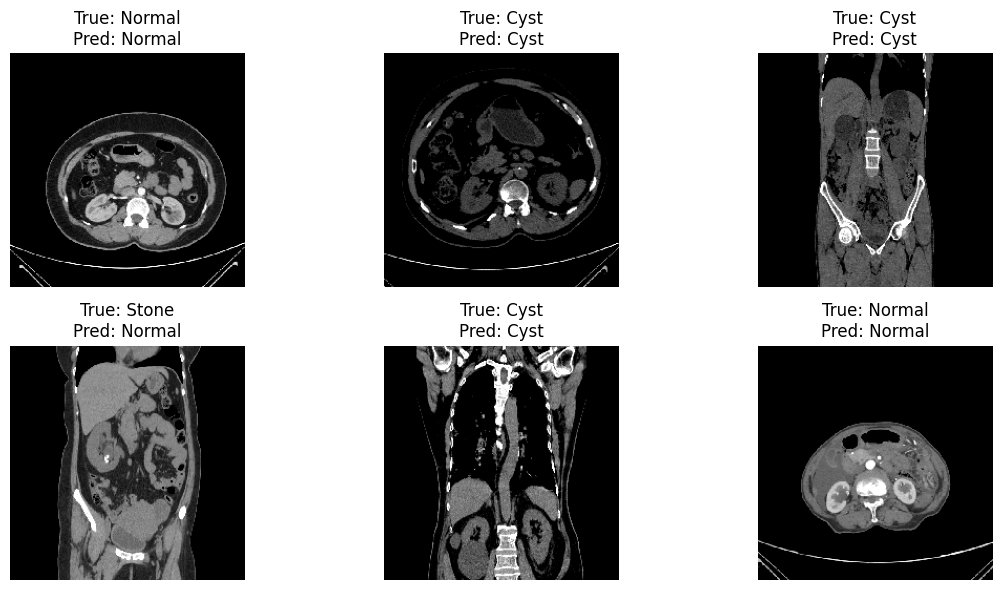

In [ ]:
# --- 3. Sample Predictions ---
import matplotlib.pyplot as plt

# Get some sample images from the generator
test_images, test_labels = next(test_gen)  # first batch
pred_classes = np.argmax(model.predict(test_images), axis=1)
true_classes = np.argmax(test_labels, axis=1)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(test_images[i])
    plt.title(f"True: {list(test_gen.class_indices.keys())[true_classes[i]]}\nPred: {list(test_gen.class_indices.keys())[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

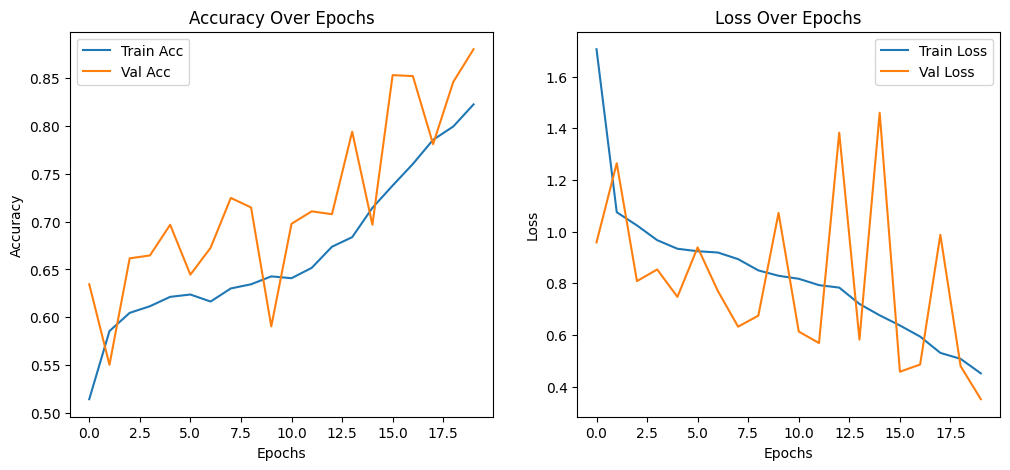

In [ ]:
# --- 4. Training Curves (Accuracy & Loss) ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()